# Group analysis of columns data

## Load data

In [12]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_valid.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

type = 'md'

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S03017', 'S02266', 'S02363', 'S02765', 'S01621', 'S03225', 'S03343', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987', 'S02485', 'S01412']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',
       'ethnicity',

In [13]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [14]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [15]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel(type)
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + type + '_' + region + '.png')
    plt.close()


In [16]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

In [17]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.67825758 -0.93189112 -0.85539892]
 [-2.12139645  1.07308674  1.16904519]
 [-1.02286429 -0.93189112  1.16904519]
 [-0.36858664 -0.93189112 -0.85539892]
 [ 1.0053964  -0.93189112  1.16904519]
 [-0.56486994  1.07308674 -0.85539892]
 [ 0.92034031 -0.93189112 -0.85539892]
 [-1.80799746  1.07308674 -0.85539892]
 [-1.41543087  1.07308674 -0.85539892]
 [ 0.52515662 -0.93189112 -0.85539892]
 [ 0.08940771  1.07308674 -0.85539892]
 [-0.65516025 -0.93189112  1.16904519]
 [-0.76115323 -0.93189112 -0.85539892]
 [ 1.66817966  1.07308674 -0.85539892]
 [ 1.9213851  -0.93189112 -0.85539892]
 [ 0.22026323  1.07308674  1.16904519]
 [-0.49944217  1.07308674 -0.85539892]
 [-2.06970851 -0.93189112  1.16904519]
 [-1.41543087 -0.93189112 -0.85539892]
 [-0.95743652 -0.93189112 -0.85539892]
 [ 0.8359385   1.07308674 -0.85539892]
 [-1.41543087 -0.93189112  1.16904519]
 [-0.69572547  1.07308674 -0.85539892]
 [ 0.74368535 -0.93189112 -0.85539892]
 [ 0.93996864  1.07308674  1.16904519]
 [ 0.54740206 -0.93189112

lh_bankssts
Weights:
[[ 0.00459706 -0.00043192  0.00305593]
 [ 0.01094129 -0.00064324  0.00387911]
 [ 0.06363976  0.0035352   0.01514953]]
MSE:
0.002143159417710806
R2:
0.21085276210231862


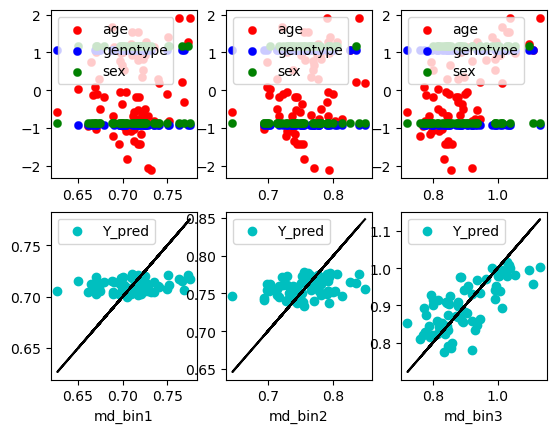

lh_caudalanteriorcingulate
lh_caudalmiddlefrontal
lh_cuneus
Weights:
[[ 0.00953172 -0.00089808 -0.00362504]
 [ 0.01618733 -0.00926219  0.01217672]
 [ 0.04959011 -0.00608937  0.04285584]]
MSE:
0.003187747281355716
R2:
0.2320607609333805


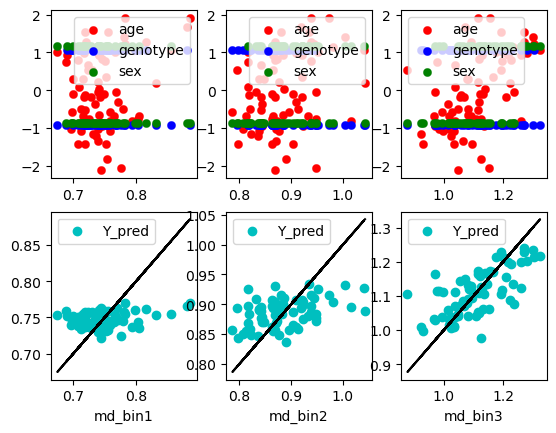

lh_entorhinal
lh_fusiform
Weights:
[[ 0.00698736  0.0020073  -0.0053629 ]
 [ 0.02142501  0.00176681 -0.00105542]
 [ 0.06619945  0.00273531  0.00512749]]
MSE:
0.0017504642684295418
R2:
0.3120251038871877


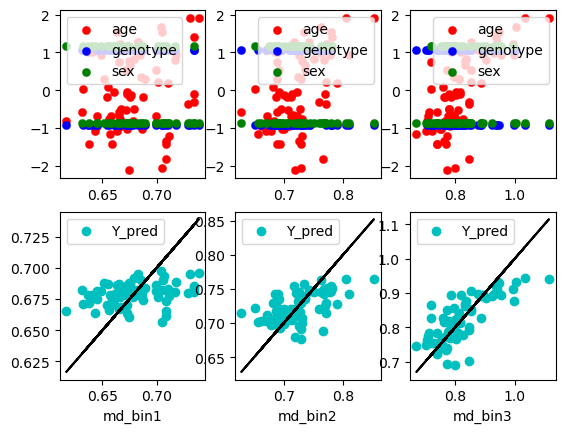

lh_inferiorparietal
Weights:
[[ 0.00482317 -0.00161957 -0.001296  ]
 [ 0.01357003 -0.00244249 -0.0017101 ]
 [ 0.06457596 -0.0002426   0.01042015]]
MSE:
0.002145188744297311
R2:
0.22138987350760975


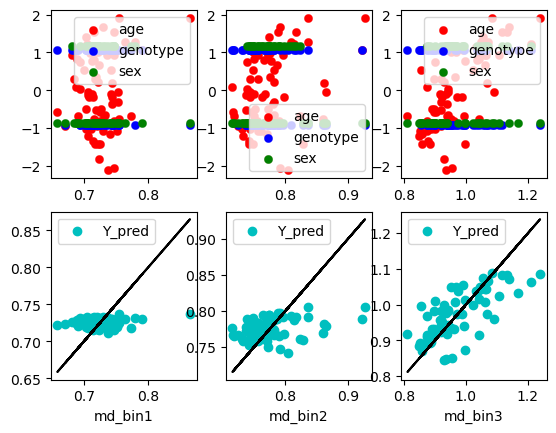

lh_inferiortemporal
Weights:
[[0.00994368 0.00195183 0.00241693]
 [0.02090842 0.00207288 0.00513736]
 [0.0508012  0.00140941 0.01051039]]
MSE:
0.002311126664229271
R2:
0.23025406397216688


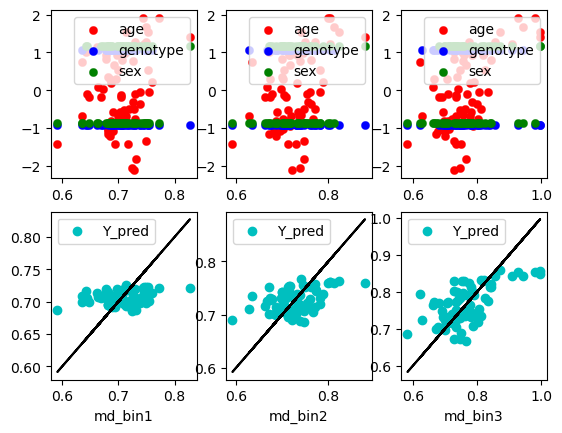

lh_isthmuscingulate
Weights:
[[ 0.01542365 -0.00264774  0.00345841]
 [ 0.03088707 -0.00078768  0.01002502]
 [ 0.05874224  0.00486726  0.01476586]]
MSE:
0.0031492236872054727
R2:
0.2889532160899478


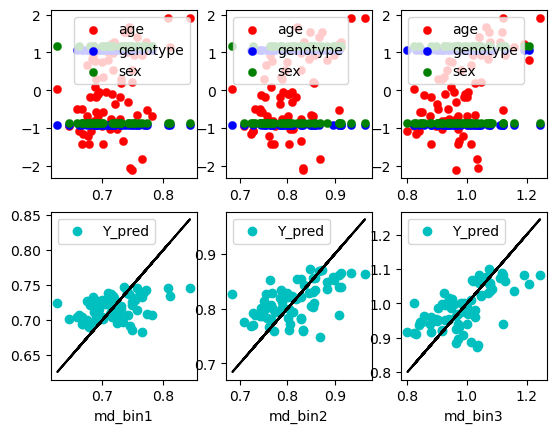

lh_lateraloccipital
Weights:
[[ 0.02084399  0.00796113 -0.00748636]
 [ 0.03082869  0.00369199  0.00624039]
 [ 0.05117826 -0.00074771  0.03461932]]
MSE:
0.004778574335954728
R2:
0.2381881970856635


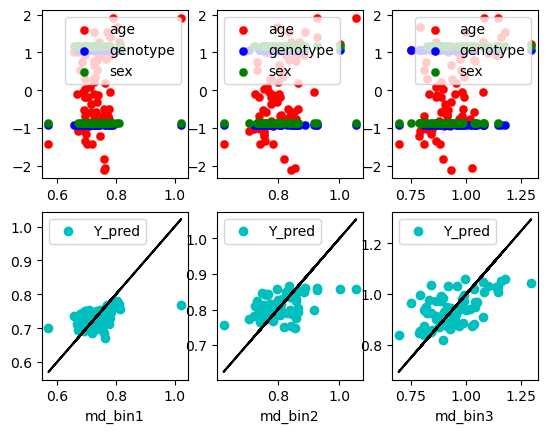

lh_lateralorbitofrontal
lh_lingual
Weights:
[[ 0.01667596 -0.00141217  0.00426419]
 [ 0.03492751 -0.00229775  0.01238127]
 [ 0.07278419  0.00122547  0.01714474]]
MSE:
0.004069492957726997
R2:
0.2935950532831462


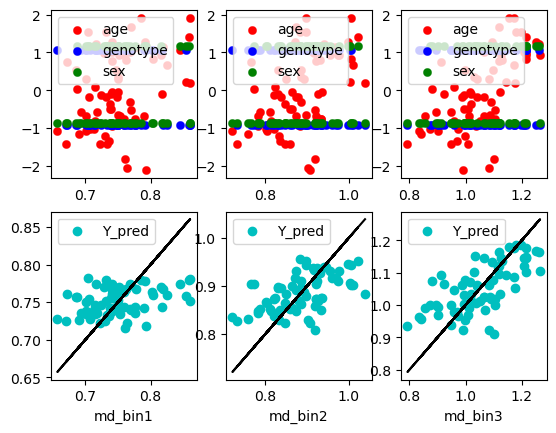

lh_medialorbitofrontal
lh_middletemporal
Weights:
[[ 7.58406220e-03  2.03386688e-03  4.36897686e-03]
 [ 1.78324844e-02 -6.19999474e-05  3.55350187e-03]
 [ 6.26423389e-02 -6.94687364e-03  7.97865089e-03]]
MSE:
0.0018054096888306071
R2:
0.28102816950251047


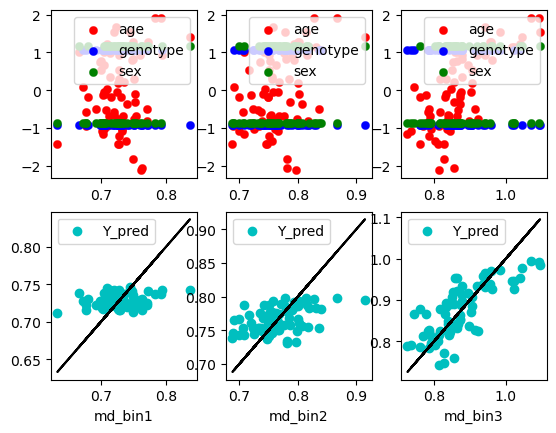

lh_parahippocampal
Weights:
[[ 0.00903973  0.00025916 -0.00737196]
 [ 0.02164926  0.00628994 -0.00053666]
 [ 0.05161938  0.00839847  0.00286159]]
MSE:
0.0026319199210147
R2:
0.21455708446797803


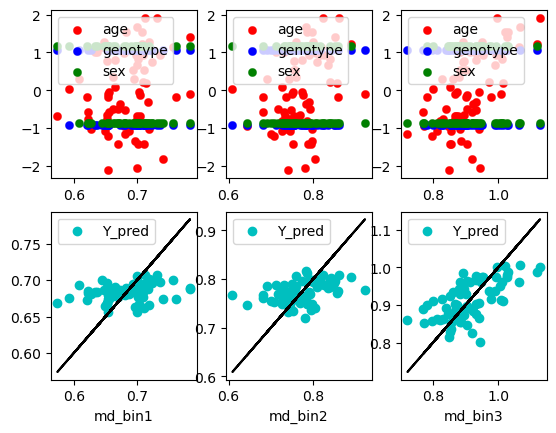

lh_paracentral
Weights:
[[ 0.00793207 -0.00725546  0.00210234]
 [ 0.01663801 -0.00713672  0.00714174]
 [ 0.05918297 -0.01643692  0.0362144 ]]
MSE:
0.0031308669573491487
R2:
0.24751277049102893


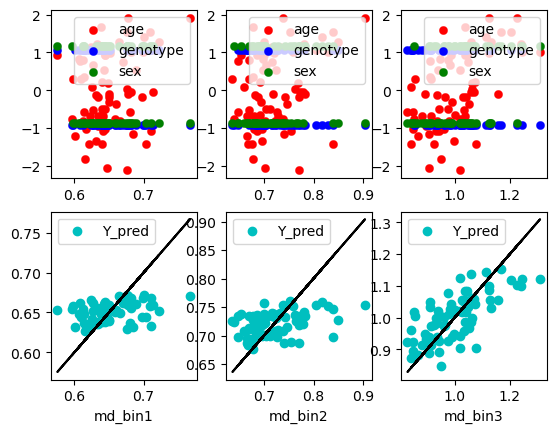

lh_parsopercularis
lh_parsorbitalis
lh_parstriangularis
Weights:
[[ 0.00619631 -0.00287988 -0.00429486]
 [ 0.01490186  0.00121078 -0.00819771]
 [ 0.05280617  0.00863194  0.00811726]]
MSE:
0.0022780003471777905
R2:
0.205227562327194


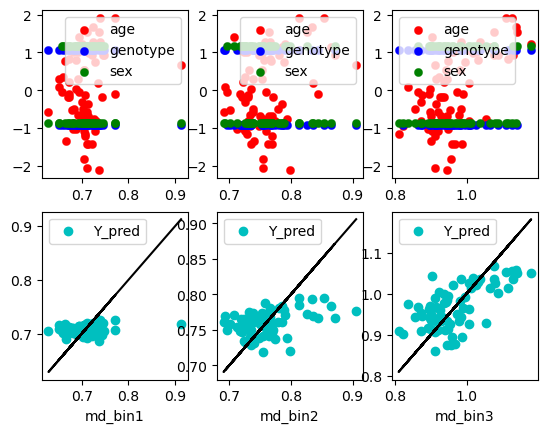

lh_pericalcarine
Weights:
[[ 0.02349557 -0.00315895 -0.00294724]
 [ 0.03984212 -0.00644846  0.01541305]
 [ 0.06433915  0.00040234  0.04399314]]
MSE:
0.004160828907429801
R2:
0.3531252626173896


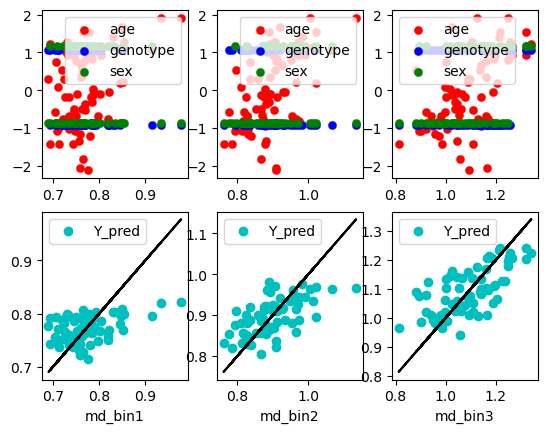

lh_postcentral
lh_posteriorcingulate
lh_precentral
lh_precuneus
Weights:
[[ 0.00661798 -0.00270722 -0.00216176]
 [ 0.01702297 -0.00533324  0.00030852]
 [ 0.06242343 -0.00124833  0.01165828]]
MSE:
0.002217003296507192
R2:
0.2460401230064093


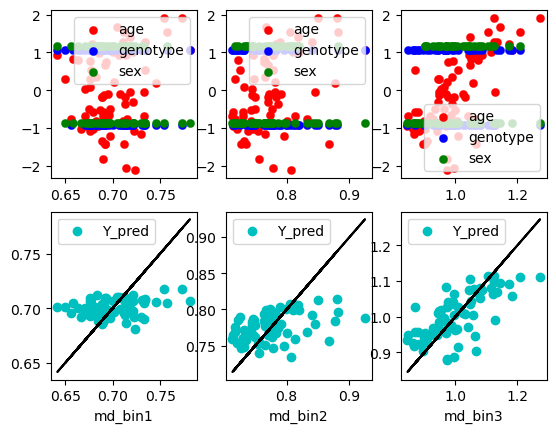

lh_rostralanteriorcingulate
lh_rostralmiddlefrontal
lh_superiorfrontal
lh_superiorparietal
lh_superiortemporal
lh_supramarginal
Weights:
[[ 0.00454069 -0.00566744  0.00098688]
 [ 0.01644484 -0.00946723 -0.00234962]
 [ 0.0634731  -0.00803706  0.00304374]]
MSE:
0.002236715368551313
R2:
0.2569899199696824


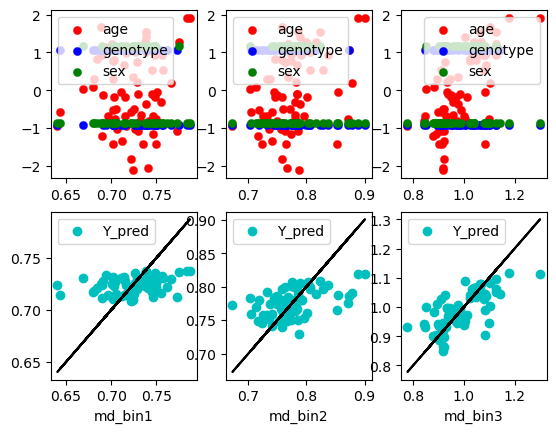

lh_frontalpole
lh_temporalpole
lh_transversetemporal
lh_insula
Weights:
[[ 0.01039255  0.00546632 -0.00094653]
 [ 0.01210415  0.00579851 -0.00338266]
 [ 0.04934889  0.00761049  0.00312468]]
MSE:
0.0019576725175887
R2:
0.21696876430511688


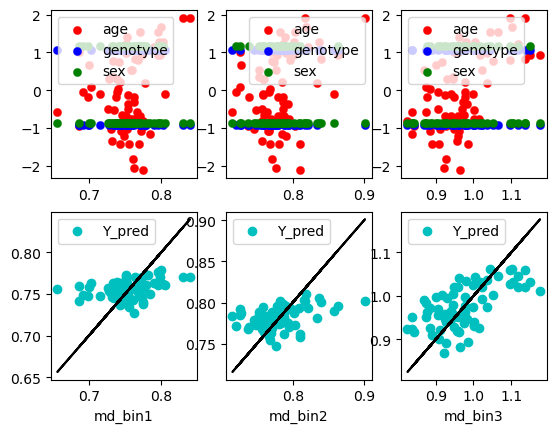

In [19]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y_pred - Y) ** 2)

    if r2 > 0.2:
        print('Weights:')
        print(weights)
        print('MSE:')
        print(mse)
        print('R2:')
        print(r2)
        plt.subplot(2, 3, 1)
        plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 4)
        plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
        plt.plot(Y[:,0], Y[:,0], color='k')
        plt.legend()
        plt.xlabel(type + '_bin1')
        plt.subplot(2, 3, 2)
        plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 5)
        plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
        plt.plot(Y[:,1], Y[:,1], color='k')
        plt.legend()
        plt.xlabel(type + '_bin2')
        plt.subplot(2, 3, 3)
        plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 6)
        plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
        plt.plot(Y[:,2], Y[:,2], color='k')
        plt.legend()
        plt.xlabel(type + '_bin3')
        plt.show()


In [23]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.        ]
 [52.        ]
 [69.     

lh_bankssts
Weights:
[[0.00030938]] [[0.00072762]] [[0.00415702]]
MSE:
0.0008138084845857227 0.001274196180690463 0.004603038645891022
R2:
0.026740617536581412 0.088473523586452 0.4672326164137338


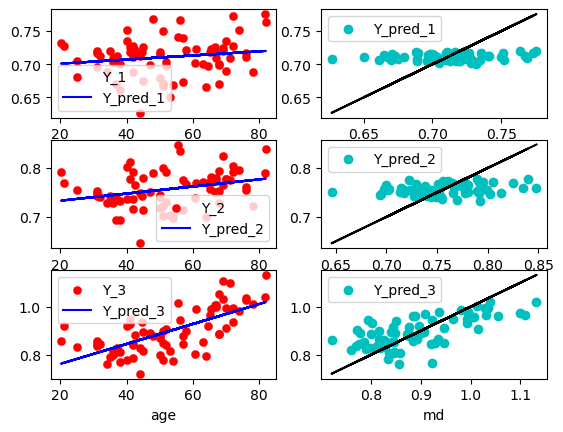

lh_caudalanteriorcingulate
Weights:
[[0.00031932]] [[0.00094287]] [[0.00270253]]
MSE:
0.0012477430705097922 0.001958914151349957 0.004116971846760633
R2:
0.018732770491181938 0.09585271057741329 0.292995229829597


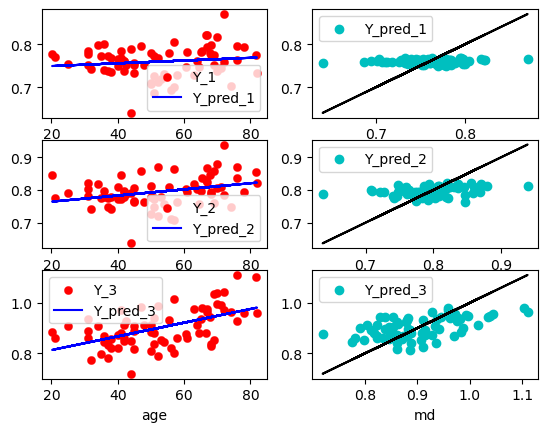

lh_caudalmiddlefrontal
Weights:
[[0.00011771]] [[0.00056378]] [[0.00337967]]
MSE:
0.0008964501514719876 0.001429319510976372 0.00396516357722328
R2:
0.0035974260918847367 0.04938303038973191 0.402243301101166


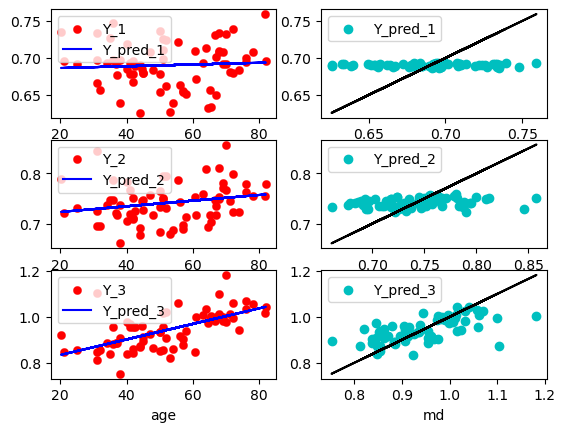

lh_cuneus
Weights:
[[0.00062572]] [[0.00115909]] [[0.00336555]]
MSE:
0.0015832095810337243 0.0028951154930146306 0.00724084717536419
R2:
0.05461389655686766 0.09780203227334594 0.26762694550670196


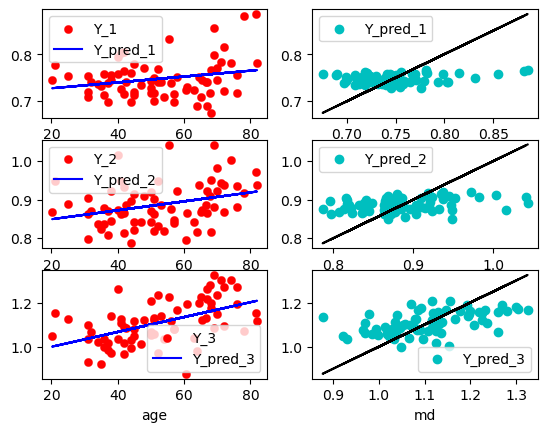

lh_entorhinal
Weights:
[[0.00025599]] [[0.0017394]] [[0.00351831]]
MSE:
0.004684395159778634 0.006278054339647523 0.008551801573114205
R2:
0.0032572782307568326 0.10118539883770516 0.2526894910322457


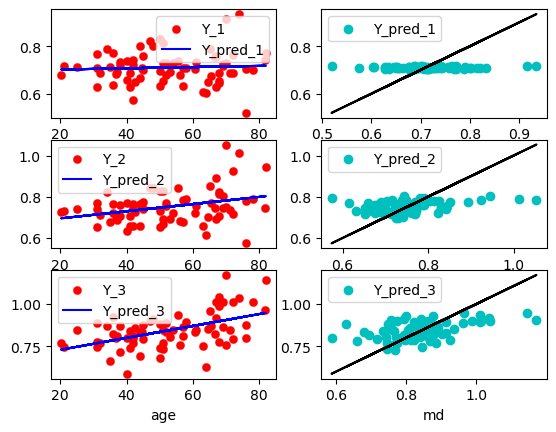

lh_fusiform
Weights:
[[0.00043118]] [[0.00138473]] [[0.00431558]]
MSE:
0.0007319747757765897 0.0012476565650893355 0.003342126028417682
R2:
0.056009832320726094 0.2641709870090302 0.5655499801574


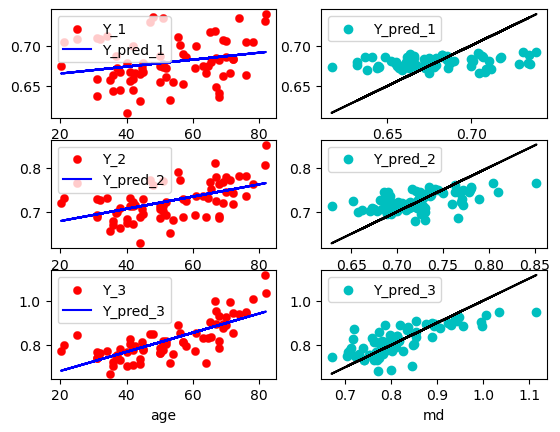

lh_inferiorparietal
Weights:
[[0.00032762]] [[0.00090643]] [[0.00424369]]
MSE:
0.0008455857412835166 0.0015474049216887382 0.004163806798464988
R2:
0.0287991797112761 0.11034604464698994 0.5025745696985148


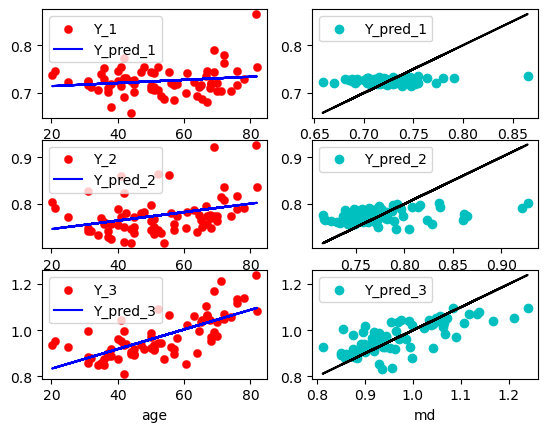

lh_inferiortemporal
Weights:
[[0.00063742]] [[0.00135808]] [[0.00332819]]
MSE:
0.0012349412426933585 0.0018158324367324602 0.004032077203620484
R2:
0.07137105233985441 0.19177069605453245 0.39089223425173714


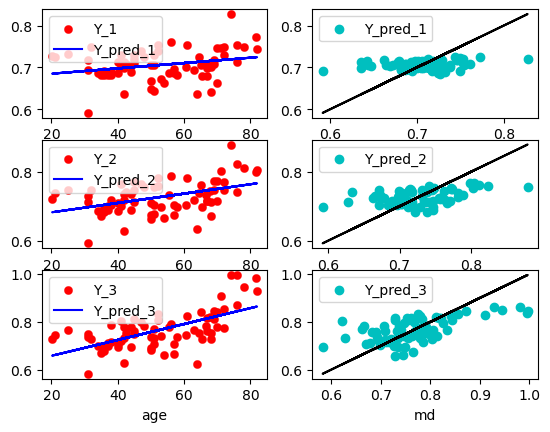

lh_isthmuscingulate
Weights:
[[0.00103768]] [[0.00204362]] [[0.00382437]]
MSE:
0.0013471642146469464 0.0025506800809078495 0.00590533026697242
R2:
0.15733947775911195 0.27666816598996125 0.3665133323285934


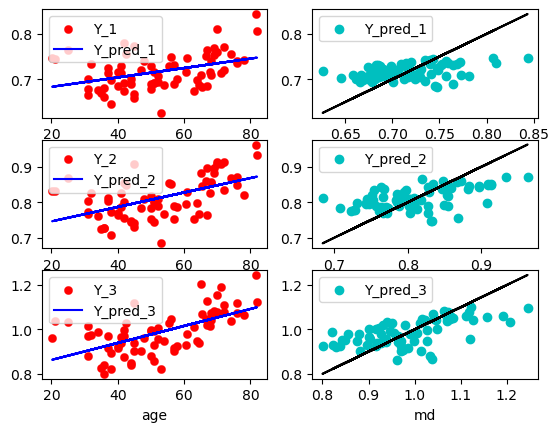

lh_lateraloccipital
Weights:
[[0.00128255]] [[0.00199478]] [[0.00340986]]
MSE:
0.0024575690494822995 0.0034863468514042175 0.00976706241822794
R2:
0.1352160908496357 0.21049796746354543 0.2175827410360862


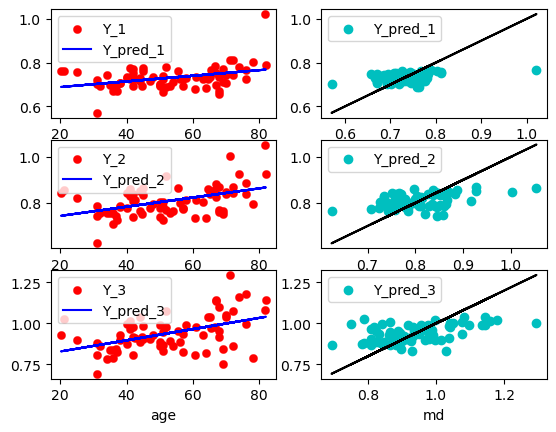

lh_lateralorbitofrontal
lh_lingual
Weights:
[[0.00111013]] [[0.00232487]] [[0.0047786]]
MSE:
0.001868292144319886 0.003762759082787704 0.007052561372198728
R2:
0.13351805724584642 0.2512490841043321 0.4306421464109623


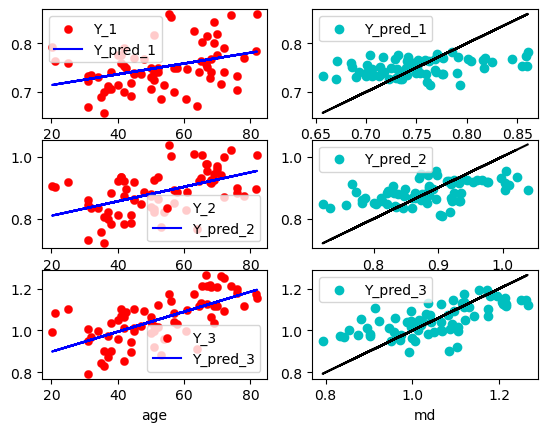

lh_medialorbitofrontal
Weights:
[[0.00106284]] [[0.00147248]] [[0.00242124]]
MSE:
0.002590032617838194 0.0031336810355709938 0.005322268048202711
R2:
0.09246392362841971 0.13913941991225354 0.20464984426111832


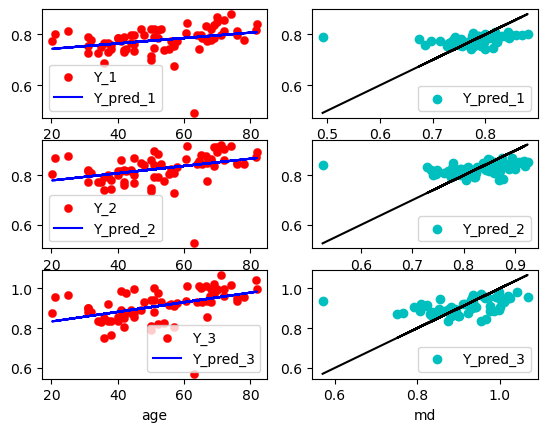

lh_middletemporal
Weights:
[[0.00048541]] [[0.00117291]] [[0.00417171]]
MSE:
0.0009803975004316423 0.001481021565577649 0.003106342357443591
R2:
0.05315884128099457 0.17830243743789032 0.5668646514319214


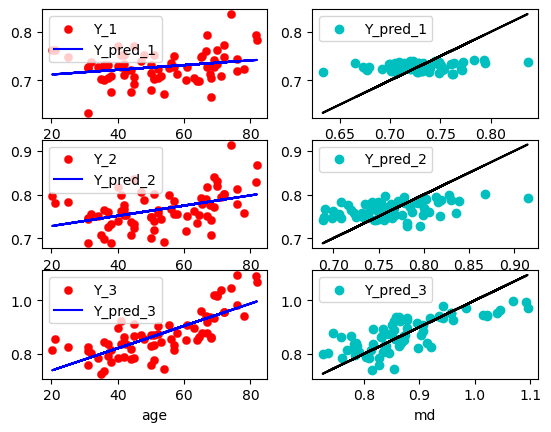

lh_parahippocampal
Weights:
[[0.00057751]] [[0.00136081]] [[0.00330871]]
MSE:
0.0015648456655301289 0.00257272514630179 0.00392728447171678
R2:
0.047426093823524806 0.14394084095454218 0.3943723456871707


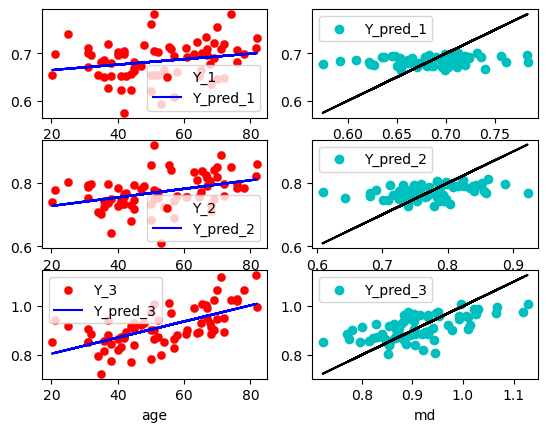

lh_paracentral
Weights:
[[0.00058552]] [[0.00116208]] [[0.00407281]]
MSE:
0.0011653627027716346 0.002661698706218533 0.0073658678332059
R2:
0.06430305419451532 0.10596120958818545 0.34471984650798926


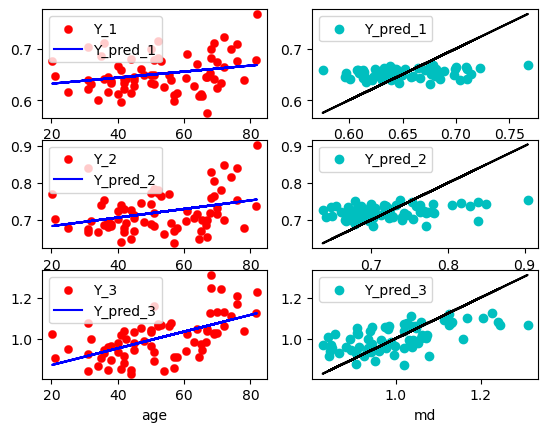

lh_parsopercularis
Weights:
[[9.95622804e-06]] [[0.00060501]] [[0.00307966]]
MSE:
0.0005999983987690465 0.0013536342195270368 0.0035802550614175144
R2:
3.859212192569572e-05 0.05941434253141398 0.3822677662487808


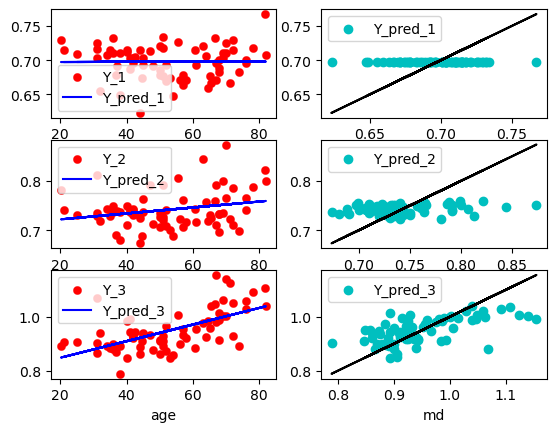

lh_parsorbitalis
Weights:
[[0.00072788]] [[0.00104377]] [[0.00272594]]
MSE:
0.0024633597179000667 0.00356176206597055 0.00454818018432872
R2:
0.04783829155404706 0.06668778752179683 0.27623025137705215


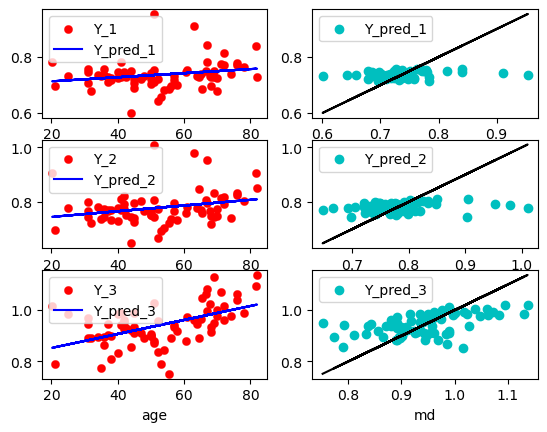

lh_parstriangularis
Weights:
[[0.00042369]] [[0.00095145]] [[0.00339265]]
MSE:
0.0013027982556558138 0.0016676801590925815 0.00409039205278665
R2:
0.03118470358254688 0.11253554186861525 0.3966235366206148


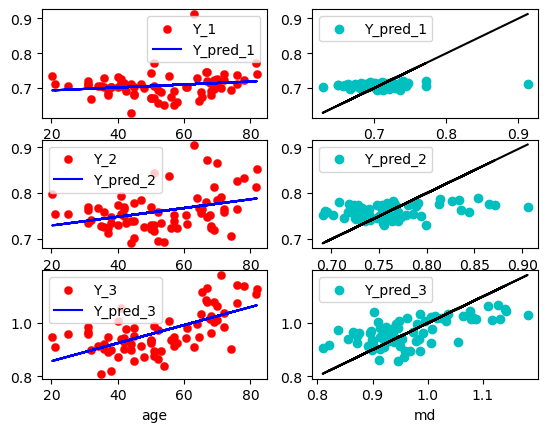

lh_pericalcarine
Weights:
[[0.00156011]] [[0.00268739]] [[0.00427579]]
MSE:
0.0023894807498956124 0.003327749466716103 0.009003769705241265
R2:
0.19221223348162064 0.33641876032666185 0.3217275856594981


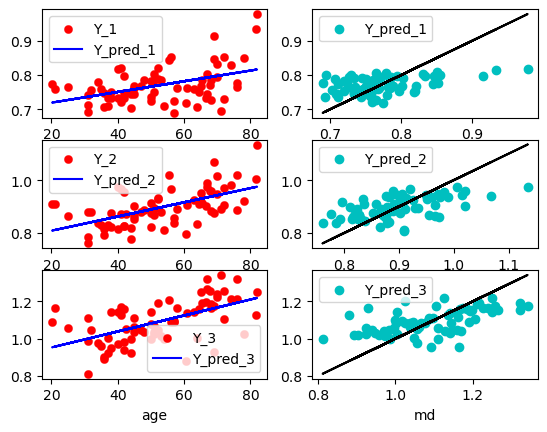

lh_postcentral
Weights:
[[0.00026181]] [[0.00094781]] [[0.00346613]]
MSE:
0.0023284451776962173 0.004892547303995369 0.0081996953149838
R2:
0.006829982965076975 0.04112862843919163 0.25499339607036653


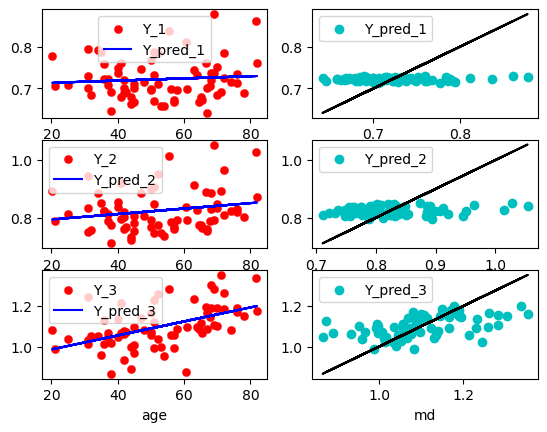

lh_posteriorcingulate
Weights:
[[0.0002893]] [[0.00083698]] [[0.0032388]]
MSE:
0.0007199353227259957 0.0012775589079030416 0.004846370658952182
R2:
0.026439343386299496 0.1135482547712845 0.3358233217404759


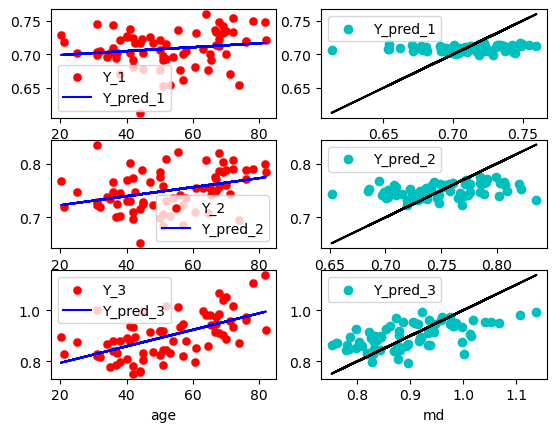

lh_precentral
Weights:
[[0.00012279]] [[0.00029394]] [[0.00276931]]
MSE:
0.0008757563396218618 0.001600190684000285 0.006285713321731659
R2:
0.004005892672002798 0.01245625438907716 0.22179737673721234


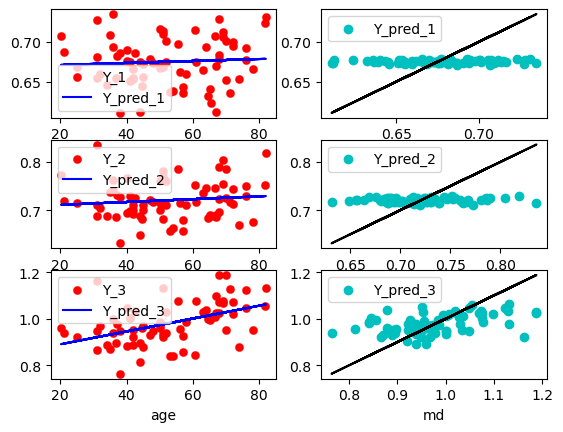

lh_precuneus
Weights:
[[0.00045316]] [[0.00116073]] [[0.00411358]]
MSE:
0.0006998173944978771 0.001679955824500309 0.004449556541523018
R2:
0.06415005123356221 0.1577834829525845 0.4704455758696853


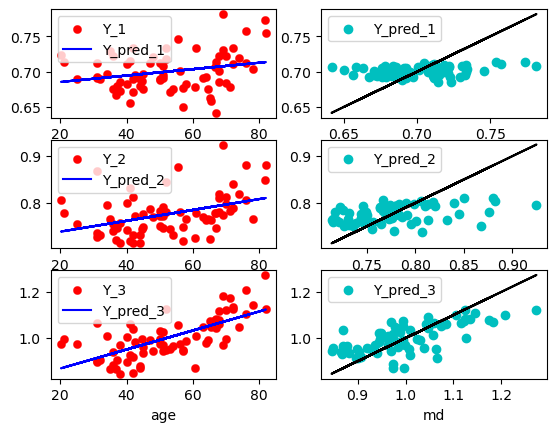

lh_rostralanteriorcingulate
Weights:
[[0.00106877]] [[0.00101162]] [[0.00216228]]
MSE:
0.001059602863880317 0.002048519250132555 0.0039268261623239525
R2:
0.20116678818818312 0.10450430370276231 0.21761174613038692


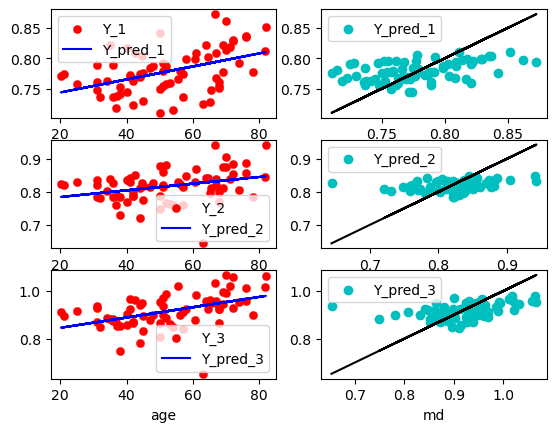

lh_rostralmiddlefrontal
Weights:
[[4.13296136e-05]] [[0.00053141]] [[0.00296445]]
MSE:
0.0008540447462675904 0.0013167195956878253 0.0035449222601169252
R2:
0.0004669980230526116 0.04771015011328539 0.36672998504634946


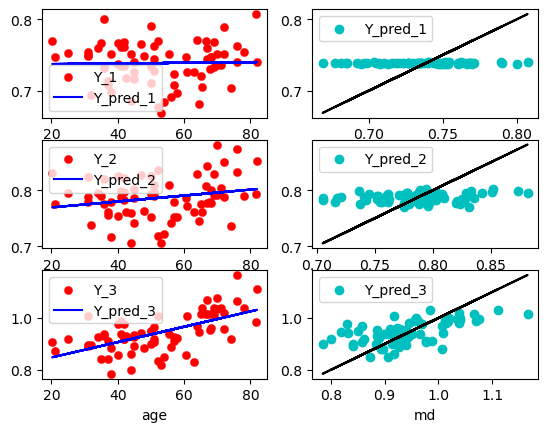

lh_superiorfrontal
Weights:
[[8.77965517e-05]] [[0.000529]] [[0.00254566]]
MSE:
0.0008709339133279409 0.0015946171826081185 0.003584054705577386
R2:
0.002063234440970896 0.03938060706157265 0.2969517709225289


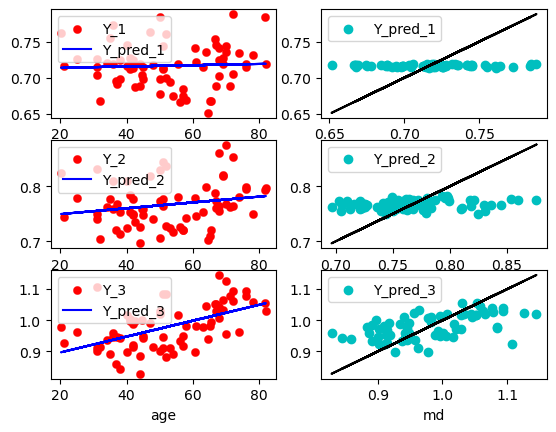

lh_superiorparietal
Weights:
[[0.00026077]] [[0.00096192]] [[0.00317337]]
MSE:
0.001042823761595106 0.002794548280964056 0.0064460380972885195
R2:
0.015003963209246352 0.07179440946922377 0.2673680549848453


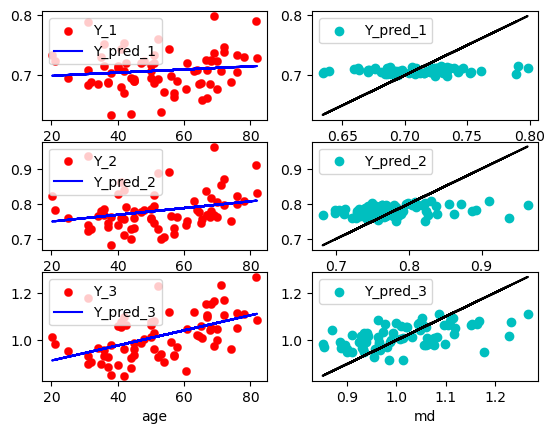

lh_superiortemporal
Weights:
[[3.01783508e-05]] [[0.00080894]] [[0.00390055]]
MSE:
0.000573561745195646 0.0015708682791329746 0.0037841702288923234
R2:
0.0003707879454704077 0.08868173669404644 0.48432312257363874


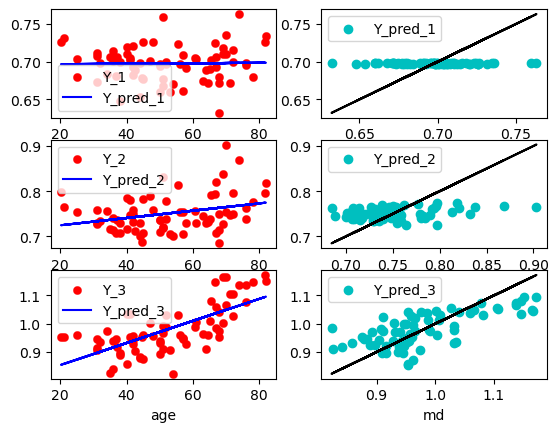

lh_supramarginal
Weights:
[[0.00034803]] [[0.0011547]] [[0.00422775]]
MSE:
0.0008301555641694812 0.0016467380022359521 0.00443283346483711
R2:
0.03295974380651745 0.15905877339132646 0.4850446393787651


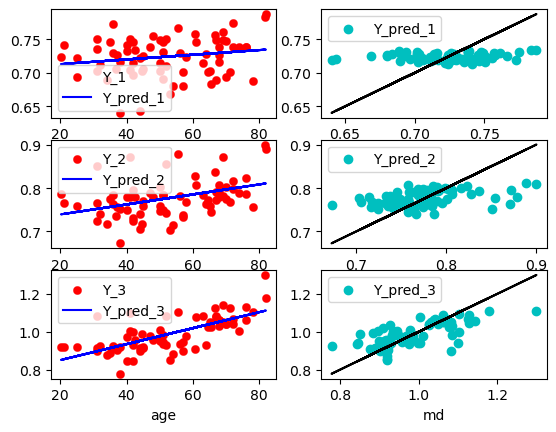

lh_frontalpole
lh_temporalpole
lh_transversetemporal
Weights:
[[-0.00054015]] [[-5.12752962e-05]] [[0.00476253]]
MSE:
0.0007506726853655536 0.0029013932506183086 0.007714748298337826
R2:
0.08323474377800322 0.0002116380135707141 0.40716094683597204


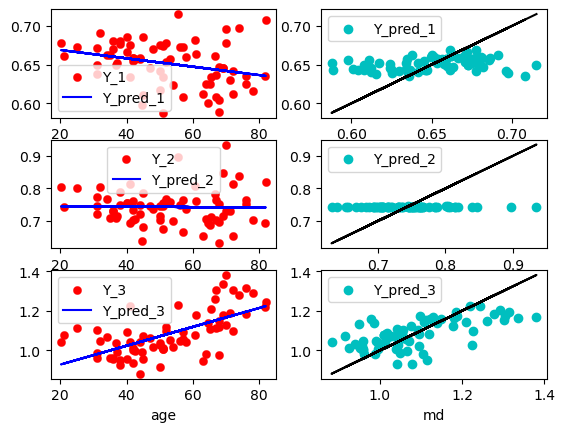

lh_insula
Weights:
[[0.00063084]] [[0.00073607]] [[0.00316744]]
MSE:
0.0009445688472092832 0.0009679372872406166 0.004101972848731243
R2:
0.08960061217404103 0.11563715820822551 0.3636030389201138


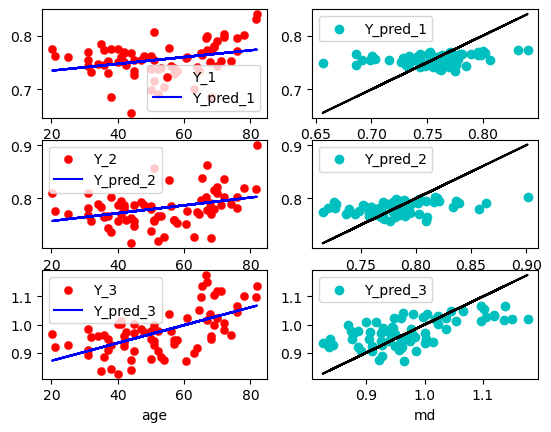

In [24]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()


rh_bankssts
Weights:
[[0.00035324]] [[0.00088363]] [[0.00415995]]
MSE:
0.0007670361905016658 0.0013407709203442696 0.005045634404620331
R2:
0.03660992292206078 0.11974823153506531 0.44481139004906434


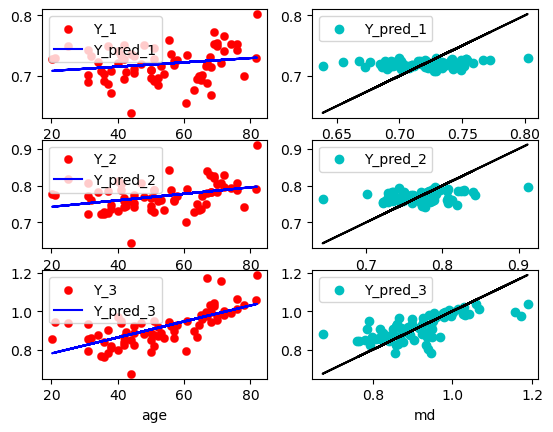

rh_caudalanteriorcingulate
Weights:
[[0.00031455]] [[0.00100723]] [[0.00282603]]
MSE:
0.0012335760611531623 0.001984020622952169 0.0041824112202703085
R2:
0.018391421879683678 0.1067043984945314 0.3084705355214923


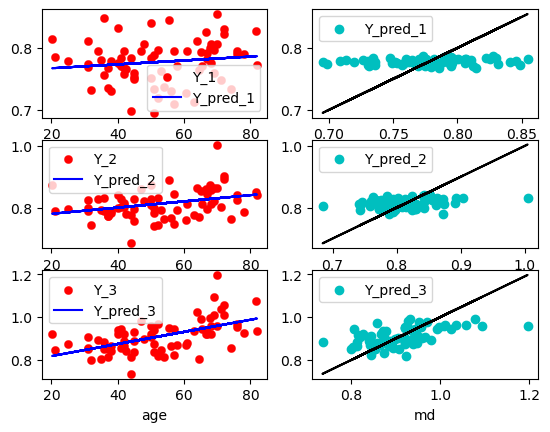

rh_caudalmiddlefrontal
Weights:
[[-0.00025409]] [[6.14761067e-06]] [[0.00322984]]
MSE:
0.0009153524119266778 0.0014210744661265354 0.0032851716302889173
R2:
0.01620889820975735 6.212537416838693e-06 0.4258774549893395


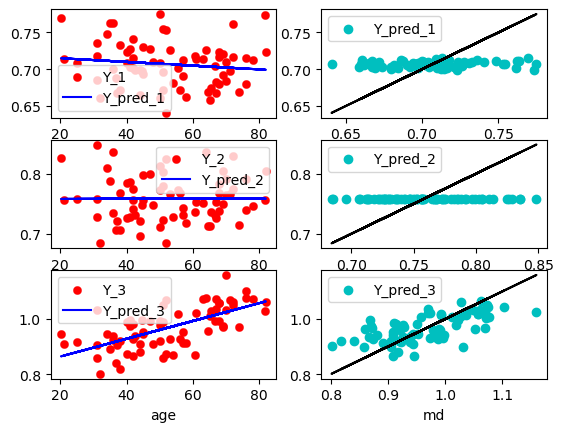

rh_cuneus
Weights:
[[0.00021577]] [[0.0012262]] [[0.0044395]]
MSE:
0.0010980819487570086 0.0027977732706776404 0.00725552698335397
R2:
0.009807264832615181 0.11153881625919249 0.38821600023525216


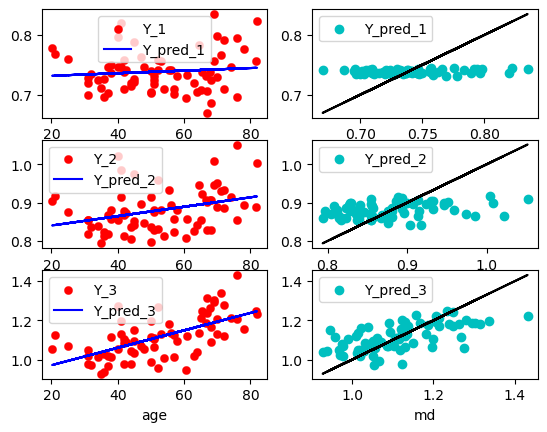

rh_entorhinal
Weights:
[[0.0006678]] [[0.00165333]] [[0.00325996]]
MSE:
0.0031056799958285946 0.005586889276095322 0.009393696564349985
R2:
0.03245465606874143 0.1025713879700878 0.20903535661346617


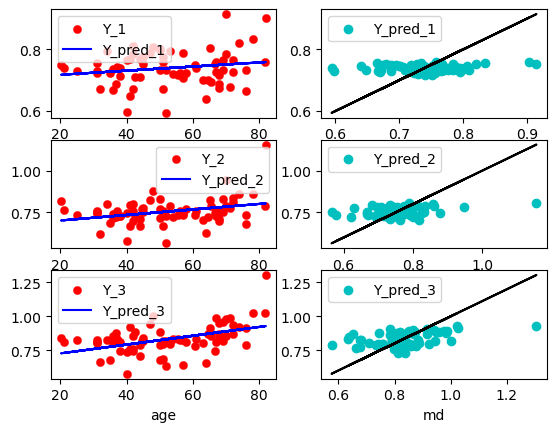

rh_fusiform
Weights:
[[0.0006662]] [[0.00166345]] [[0.00467998]]
MSE:
0.0009474825280767516 0.001684891809891229 0.004710813379002171
R2:
0.09863226444795159 0.2772686720353439 0.52063513894482


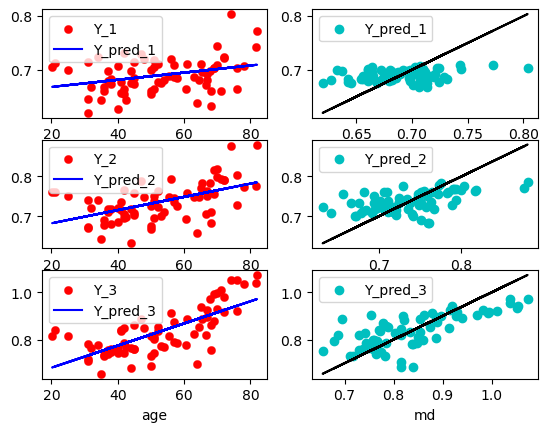

rh_inferiorparietal
Weights:
[[0.00022823]] [[0.00080763]] [[0.00398835]]
MSE:
0.0005028924162398731 0.0009380802233312054 0.0030274394908385727
R2:
0.023625380655759032 0.13973182121956784 0.551046451705977


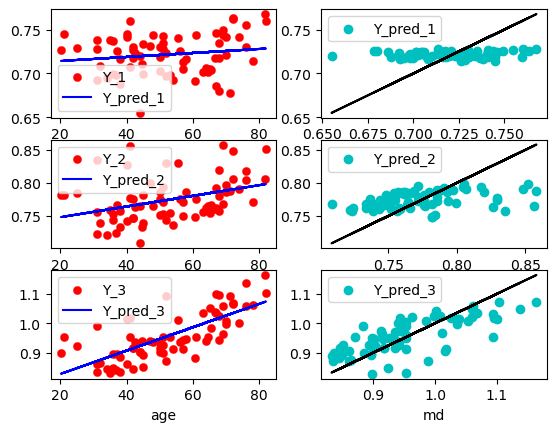

rh_inferiortemporal
Weights:
[[0.00092992]] [[0.00141324]] [[0.00295262]]
MSE:
0.0011754237489019774 0.0019406071517315635 0.0040692050273968125
R2:
0.1466560256626107 0.19382086351392958 0.3335438094210139


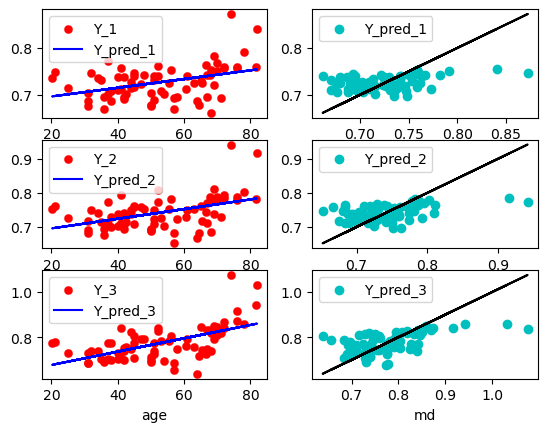

rh_isthmuscingulate
Weights:
[[0.00122796]] [[0.00216828]] [[0.00397996]]
MSE:
0.0014709722097378574 0.0032075252779956024 0.006510317568552425
R2:
0.19319977141635147 0.2550665191633421 0.36239496163410245


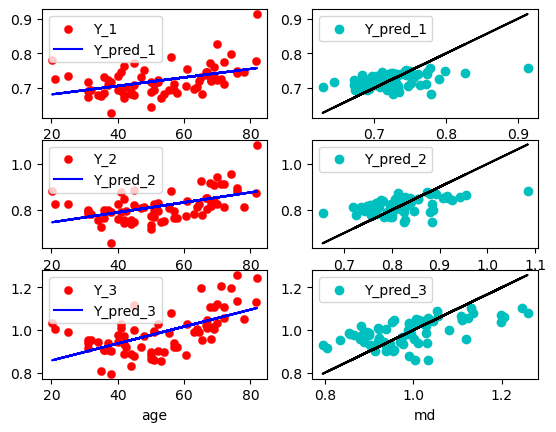

rh_lateraloccipital
Weights:
[[0.00105506]] [[0.00181745]] [[0.00333479]]
MSE:
0.0012707677441065822 0.0026698671065786715 0.008401834702906268
R2:
0.16986777184398838 0.22420980865188422 0.2361739260370287


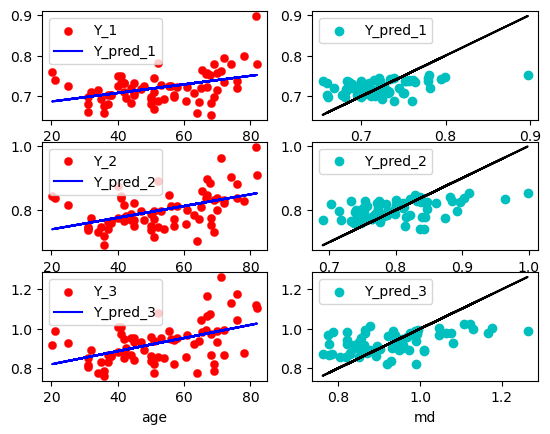

rh_lateralorbitofrontal
rh_lingual
Weights:
[[0.00093864]] [[0.00233504]] [[0.00503889]]
MSE:
0.0019729711194698546 0.0037438893213962315 0.00808272855448259
R2:
0.09446296911339747 0.2538459567517958 0.42323748483388024


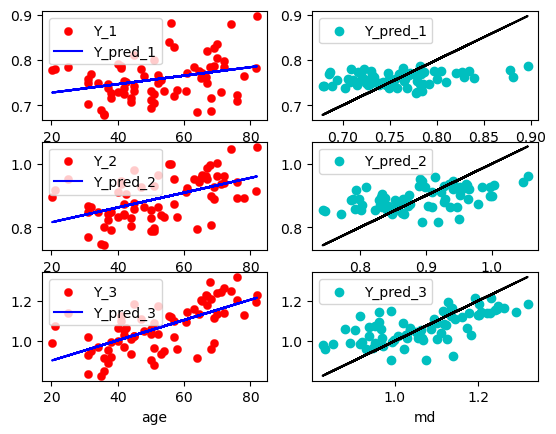

rh_medialorbitofrontal
Weights:
[[0.00150883]] [[0.001995]] [[0.00298248]]
MSE:
0.0021254950647882297 0.002508689113239098 0.0036492715574967154
R2:
0.2001307104147272 0.2703972079124607 0.36281757084918564


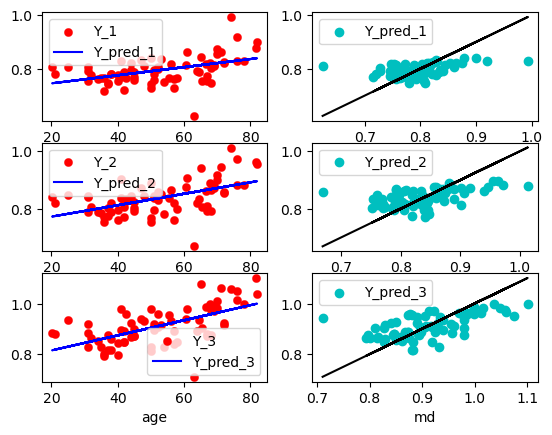

rh_middletemporal
Weights:
[[0.00056957]] [[0.001216]] [[0.00394421]]
MSE:
0.0009046767575549884 0.001364682835356741 0.0031912642881081416
R2:
0.07729321163422198 0.20198694156964292 0.5324402348345666


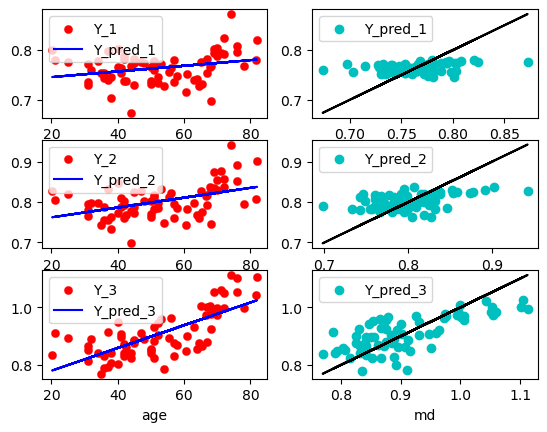

rh_parahippocampal
Weights:
[[0.00081512]] [[0.00158192]] [[0.00360412]]
MSE:
0.0018158848249726015 0.003227514661407141 0.004697376127136764
R2:
0.07874336767873269 0.15334827787859284 0.39245965935840466


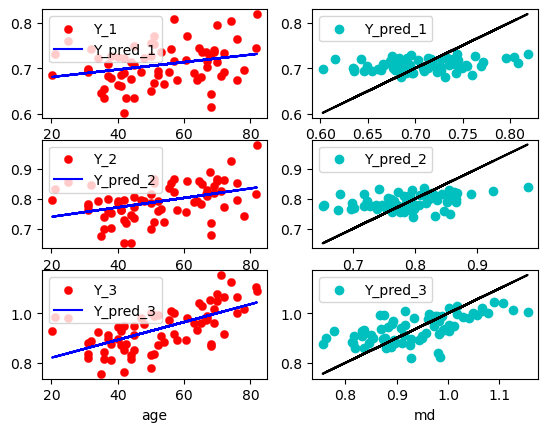

rh_paracentral
Weights:
[[0.00039114]] [[0.00078458]] [[0.00327996]]
MSE:
0.0009188626194616748 0.0020948923048663935 0.007163146135957821
R2:
0.03743882136937393 0.0642327770652864 0.259719428295349


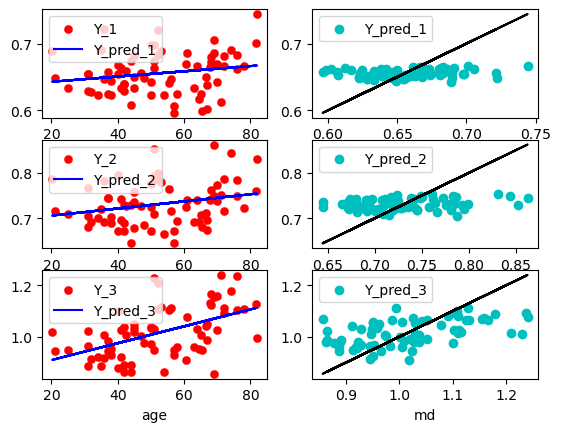

rh_parsopercularis
Weights:
[[0.00021054]] [[0.00064775]] [[0.00308622]]
MSE:
0.00073436728663488 0.0012459139867742614 0.0034035495530005014
R2:
0.013904332424742982 0.0729321489360788 0.39530653828241236


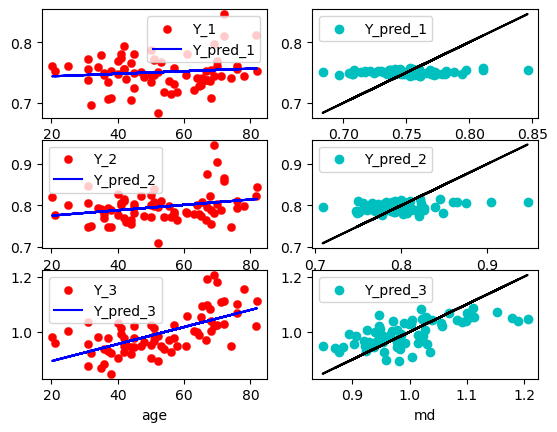

rh_parsorbitalis
Weights:
[[0.0005921]] [[0.00095288]] [[0.00336919]]
MSE:
0.0011704128632384337 0.002371067578304264 0.004577544007623569
R2:
0.06539718236006609 0.08211018732633302 0.36680299779214487


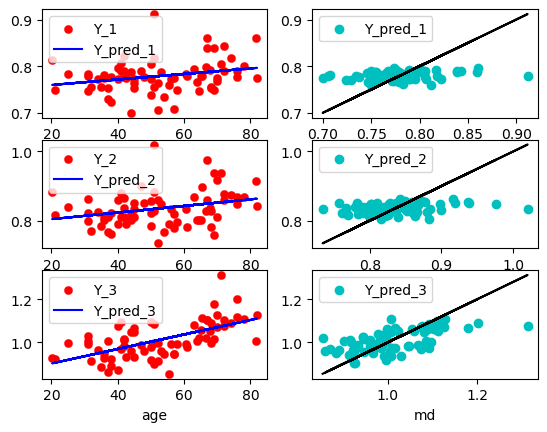

rh_parstriangularis
Weights:
[[0.00033946]] [[0.00087897]] [[0.00336426]]
MSE:
0.0008884530621216692 0.0016874234693154261 0.005156331352385727
R2:
0.02940813100074513 0.09662142861691625 0.3389571190728984


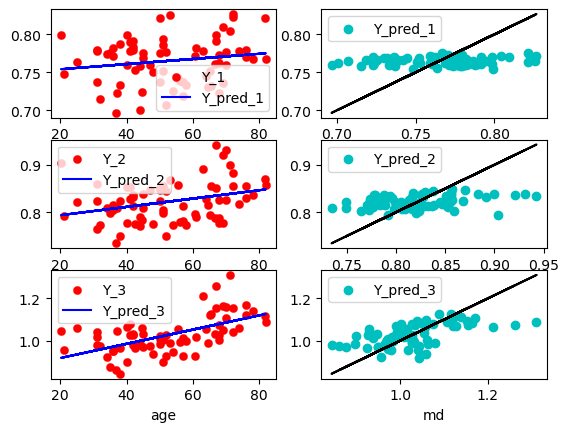

rh_pericalcarine
Weights:
[[0.00135576]] [[0.00256241]] [[0.00460362]]
MSE:
0.002309942263378124 0.0039572519177688715 0.009103823846263999
R2:
0.15674601652061815 0.279329561594975 0.35225383276858213


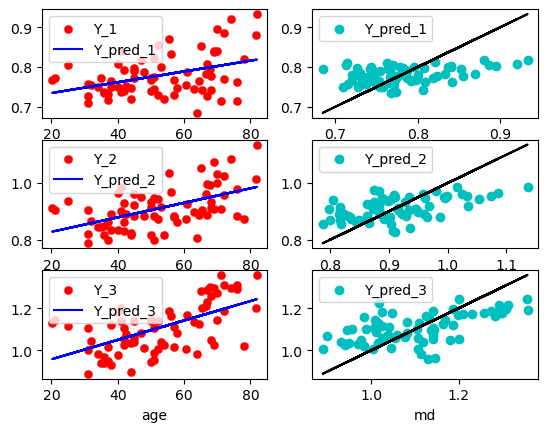

rh_postcentral
Weights:
[[-0.00033168]] [[0.00031573]] [[0.00303046]]
MSE:
0.0015070703028519077 0.0030657133310397783 0.004931713209904916
R2:
0.01676627482537707 0.007538445821961393 0.30313856436205433


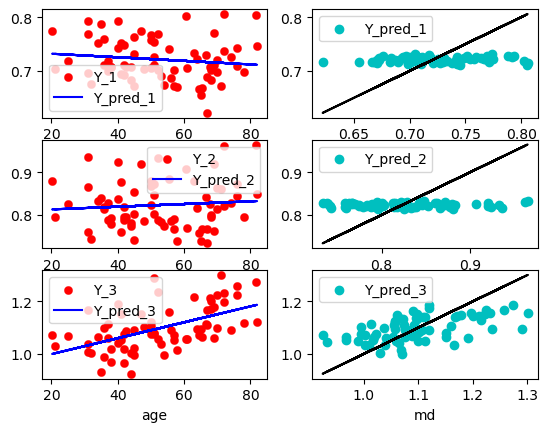

rh_posteriorcingulate
Weights:
[[0.00015775]] [[0.00068603]] [[0.00326834]]
MSE:
0.000788456955385118 0.0011089633161277196 0.003969002706765273
R2:
0.0073191668378467245 0.09019721736325137 0.386016835396796


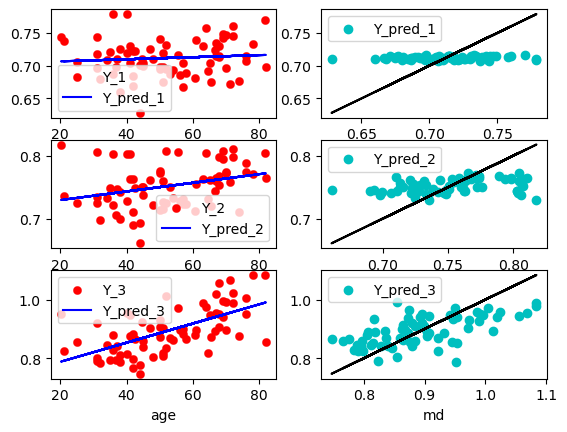

rh_precentral
Weights:
[[-0.00036128]] [[-6.83737466e-05]] [[0.00293736]]
MSE:
0.0006705233685144399 0.001048228240620068 0.005585579525937333
R2:
0.043495884987251654 0.0010407502214063724 0.26516258572641593


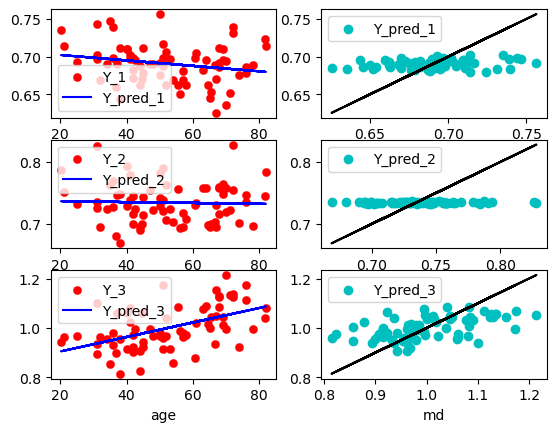

rh_precuneus
Weights:
[[0.00037746]] [[0.00115359]] [[0.00391078]]
MSE:
0.000678500678998089 0.0014449916478126974 0.0040696624591280775
R2:
0.046759132399121994 0.17704581344554005 0.4674894307211207


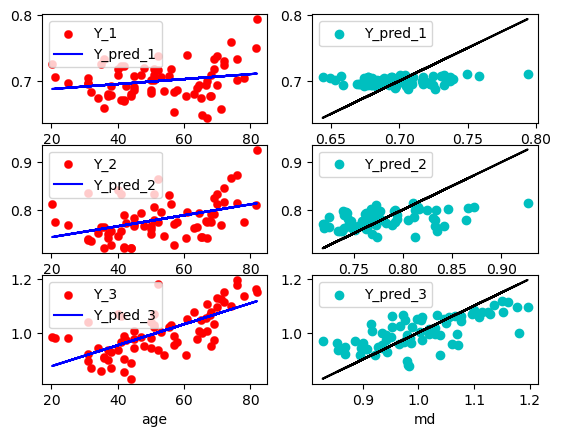

rh_rostralanteriorcingulate
Weights:
[[0.00022572]] [[0.00060958]] [[0.0025275]]
MSE:
0.0009459592463898151 0.0013709855819108992 0.002807570311045349
R2:
0.01242544989694594 0.059545287569836125 0.3470579881756253


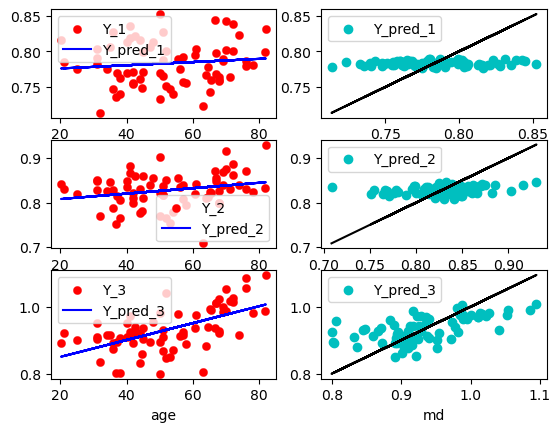

rh_rostralmiddlefrontal
Weights:
[[8.48435352e-05]] [[0.00060503]] [[0.00319246]]
MSE:
0.000821566611679986 0.001371089789192801 0.003597442924585432
R2:
0.0020425964601089586 0.05870766974447017 0.398246385864356


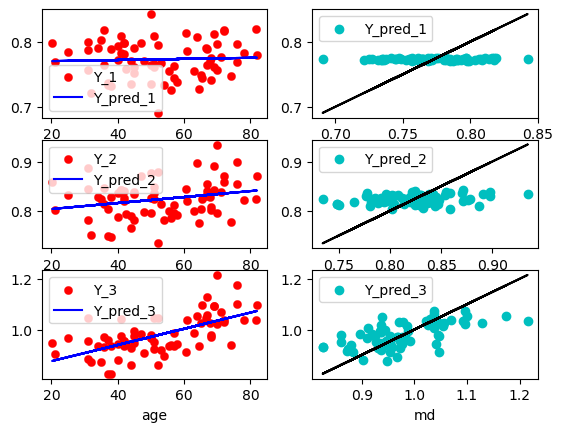

rh_superiorfrontal
Weights:
[[-6.3134965e-06]] [[0.00044856]] [[0.00249303]]
MSE:
0.0008132151662402743 0.0012872069123598133 0.0032094912340833136
R2:
1.1449994691381526e-05 0.035227851558103485 0.31147083935093667


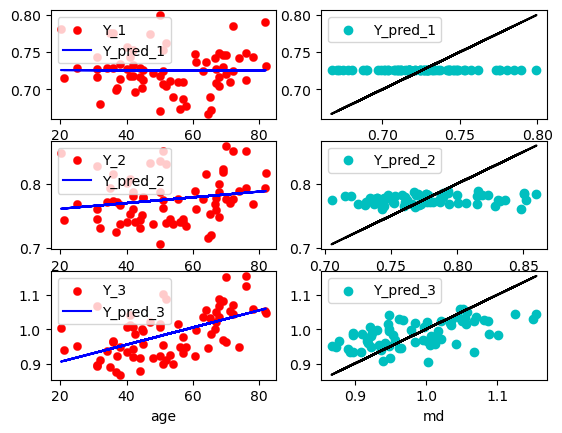

rh_superiorparietal
Weights:
[[9.13681258e-05]] [[0.00064722]] [[0.00272189]]
MSE:
0.0009461619809064415 0.002308355245117781 0.005951195530804247
R2:
0.0020568639915403697 0.04066720458849393 0.2252937442504077


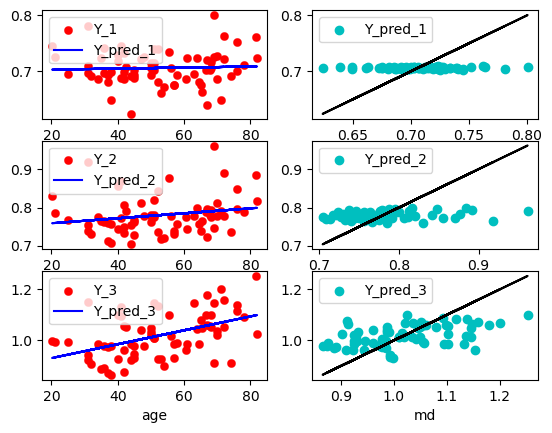

rh_superiortemporal
Weights:
[[0.0004992]] [[0.00120023]] [[0.00426738]]
MSE:
0.0010396034643234359 0.0019253033387065094 0.003989432960695743
R2:
0.0530274325246225 0.14878083561007538 0.5160477658407815


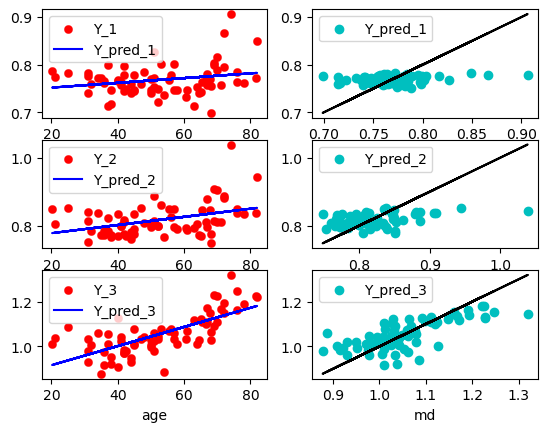

rh_supramarginal
Weights:
[[0.00021182]] [[0.00095855]] [[0.00424198]]
MSE:
0.0006147804700985015 0.001172387038226646 0.003238639293017108
R2:
0.016762307520906905 0.1547478723807585 0.5648253301102883


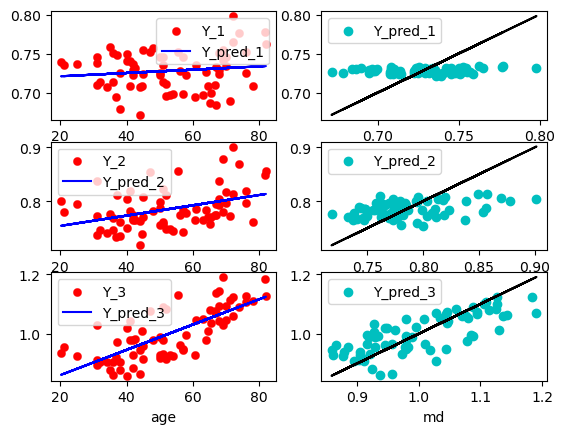

rh_frontalpole
rh_temporalpole
rh_transversetemporal
Weights:
[[-0.00027167]] [[-2.77751202e-05]] [[0.00565566]]
MSE:
0.00113675713618432 0.003923130992244328 0.010603653750919246
R2:
0.014940043157356753 4.5934074973441597e-05 0.4133764776719765


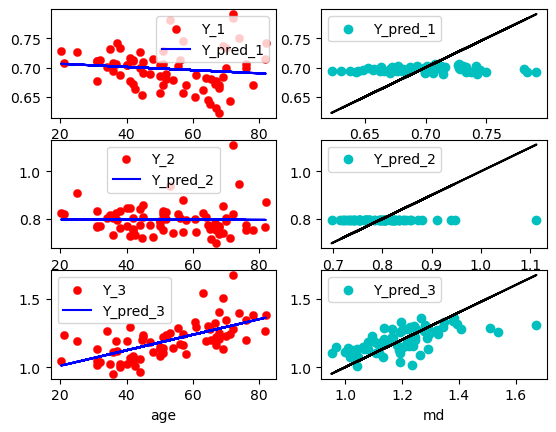

rh_insula
Weights:
[[0.00101425]] [[0.00120017]] [[0.00358136]]
MSE:
0.0012358119704280867 0.001510592077993522 0.004258087241494379
R2:
0.16279764365428007 0.18216938974835362 0.4130255878081476


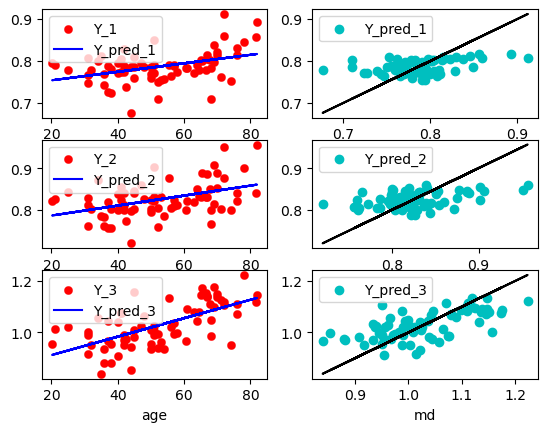

In [22]:
# For left hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()
